In [1]:
# 🔧 Βασικές
import pandas as pd
import numpy as np

# 📊 Visualizations
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')  # προαιρετικό, για καλύτερο styling

# 🔗 Για τα raw δεδομένα (SQL)
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

# 📦 Για parquet (αν θες polars alternative)
import polars as pl  # προαιρετικό, πιο γρήγορο για μεγάλα αρχεία

# ⚙️ Setup
load_dotenv()
DB_URL = os.getenv("DATABASE_URL")
engine = create_engine(DB_URL, pool_pre_ping=True)

In [3]:
import pandas as pd

def inspect_table(table_name, engine):
    print(f"\n{'='*60}")
    print(f"🔍 ΕΛΕΓΧΟΣ ΠΙΝΑΚΑ: {table_name}")
    print(f"{'='*60}\n")
    
    # 1. Φόρτωση (LIMIT 1000 για γρήγορο exploratory check)
    try:
        df = pd.read_sql(f"SELECT * FROM {table_name} ", engine)
    except Exception as e:
        print(f"⚠️ Σφάλμα φόρτωσης πίνακα '{table_name}': {e}")
        return
    if df.empty:
        print("⚠️ Ο πίνακας είναι κενός.")
        return

    # 1. Δομή
    print("1. 📐 ΔΟΜΗ:")
    print(f"   Shape: {df.shape}")
    print(f"   Στήλες: {df.columns.tolist()}")
    print(f"   Τύποι: {df.dtypes.to_dict()}\n")

    # 2. Missing values
    print("2. ⚠️ MISSING VALUES:")
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    missing_df = pd.DataFrame({"Missing": missing, "Pct%": missing_pct})
    missing_df = missing_df[missing_df["Missing"] > 0]
    if not missing_df.empty:
        print(missing_df.to_string())
    else:
        print("   ✅ Κανένα missing value\n")

    # 3. Βασικά stats (μόνο για numeric)
    print("\n3. 📊 BASIC STATS (numeric):")
    print(df.describe().to_string(), "\n")

    # 4. Μοναδικές τιμές (αυτόματη ανίχνευση categorical)
    print("4. 🔤 UNIQUE CATEGORICAL VALUES:")
    cat_cols = df.select_dtypes(include=['object', 'category', 'datetime']).columns
    for col in cat_cols:
        print(f"   📍 {col} ({df[col].nunique()} unique): {df[col].value_counts().head(3).to_dict()}")
    print()

    # 5. Τυχαίο δείγμα
    print("5. 🎲 SAMPLE (5 rows):")
    print(df.sample(5).to_string(), "\n")

    # 6. Duplicates
    print("6. 🔄 DUPLICATES:")
    print(f"   Συνολικά duplicates: {df.duplicated().sum()}\n")

    # 7. Range τιμών (μόνο για numeric)
    print("7. 🔢 RANGES (numeric):")
    num_cols = df.select_dtypes(include=['number']).columns
    for col in num_cols:
        print(f"   📏 {col}: {df[col].min():.2f} – {df[col].max():.2f}")
    print(f"\n{'='*60}\n")

# 📋 Λίστα πινάκων που θέλεις να ελέγξεις
tables_to_check = [
    "raw_day_ahead_prices",
    "raw_load", 
    "raw_generation_long"
]

# 🔄 Εκτέλεση για όλους
for table in tables_to_check:
    inspect_table(table, engine)


🔍 ΕΛΕΓΧΟΣ ΠΙΝΑΚΑ: raw_day_ahead_prices

1. 📐 ΔΟΜΗ:
   Shape: (352139, 4)
   Στήλες: ['country_code', 'period_start', 'price_eur_mwh', 'ingestion_timestamp']
   Τύποι: {'country_code': dtype('O'), 'period_start': datetime64[ns, UTC], 'price_eur_mwh': dtype('float64'), 'ingestion_timestamp': datetime64[ns, UTC]}

2. ⚠️ MISSING VALUES:
   ✅ Κανένα missing value


3. 📊 BASIC STATS (numeric):
       price_eur_mwh
count  352139.000000
mean      100.303050
std        83.880912
min      -500.000000
25%        47.210000
50%        89.330000
75%       124.390000
max      2987.780000 

4. 🔤 UNIQUE CATEGORICAL VALUES:
   📍 country_code (5 unique): {'FR': 70471, 'ES': 70471, 'GR': 70399}

5. 🎲 SAMPLE (5 rows):
       country_code              period_start  price_eur_mwh              ingestion_timestamp
178740           FR 2024-04-29 22:00:00+00:00          73.73 2026-04-27 23:09:57.491405+00:00
39659            GR 2024-07-10 11:00:00+00:00          77.67 2026-04-27 23:03:58.556797+00:00
324029    

In [4]:
# ✅ SELF-CONTAINED CELL: Missing Values Audit for Parquet Files
import pandas as pd
import polars as pl
from pathlib import Path

def check_parquet_missing(file_path, key_cols=None, sample_size=None):
    """
    Ελέγχει missing values σε parquet file.
    
    Args:
        file_path: Path to parquet file
        key_cols: List of critical columns to highlight (e.g., ['price_eur_mwh', 'country_code'])
        sample_size: If set, only check a sample of rows for faster audit
    """
    path = Path(file_path)
    
    if not path.exists():
        print(f"❌ File not found: {file_path}")
        return None
    
    # Load with polars for speed, convert to pandas for familiar operations
    df = pl.read_parquet(file_path)
    
    if sample_size and len(df) > sample_size:
        df = df.sample(sample_size, seed=42)
        print(f"📊 Sampling {sample_size:,} rows from {len(df):,} total\n")
    else:
        print(f"📊 Loading full dataset: {len(df):,} rows\n")
    
    # Convert to pandas for missing value analysis
    df_pd = df.to_pandas()
    
    print(f"🗄️  PARQUET AUDIT: {path.name}")
    print("="*60)
    print(f"📐 Shape: {df_pd.shape[0]:,} rows × {df_pd.shape[1]} columns")
    print(f"💾 Memory: {df_pd.memory_usage(deep=True).sum() / 1024**2:.2f} MB\n")
    
    # Missing values per column
    missing = df_pd.isnull().sum()
    missing_pct = (missing / len(df_pd) * 100).round(2)
    
    report = pd.DataFrame({
        "Column": missing.index,
        "Missing": missing.values,
        "Pct (%)": missing_pct.values
    })
    report = report[report["Missing"] > 0].sort_values("Missing", ascending=False)
    
    if report.empty:
        print("✅ No missing values found! 🎉\n")
    else:
        print(f"⚠️  Found missing values in {len(report)} column(s):\n")
        print(report.to_string(index=False))
        print()
    
    # Highlight critical columns
    if key_cols:
        print("🔑 Critical columns check:")
        for col in key_cols:
            if col in df_pd.columns:
                nulls = df_pd[col].isnull().sum()
                pct = nulls / len(df_pd) * 100
                status = "✅" if nulls == 0 else "⚠️"
                print(f"  {status} '{col}': {nulls:,} nulls ({pct:.2f}%)")
            else:
                print(f"  ❌ '{col}' not found in file")
        print()
    
    # Quick stats for numeric columns with missing values
    numeric_missing = report.merge(
        df_pd.select_dtypes(include='number').describe().T.reset_index(),
        left_on='Column', right_on='index', how='inner'
    )
    
    if not numeric_missing.empty:
        print("📈 Stats for numeric columns with missing values:")
        for _, row in numeric_missing.head(5).iterrows():
            col = row['Column']
            mean_val = df_pd[col].mean()
            std_val = df_pd[col].std()
            print(f"  • {col}: mean={mean_val:.2f}, std={std_val:.2f}")
    
    return report


# ─────────────────────────────────────────────────────────────
# 🚀 RUN AUDIT ON YOUR PARQUET FILES
# ─────────────────────────────────────────────────────────────

print("🔍 STARTING PARQUET MISSING VALUES AUDIT\n")

# Ορίσε τα αρχεία σου εδώ
parquet_files = [
    "data/feature_matrix_train.parquet",
    "data/feature_matrix_test.parquet",
    # "data/total_processed.parquet",  # πρόσθεσε ό,τι άλλο έχεις
]

# Κρίσιμες στήλες για έμφαση (προσαρμοσμένες στο dataset σου)
critical_columns = ['price_eur_mwh', 'country_code', 'period_start', 'load_mw']

all_reports = {}

for file in parquet_files:
    print("\n" + "─"*60 + "\n")
    report = check_parquet_missing(
        file, 
        key_cols=critical_columns,
        sample_size=100_000  # για γρήγορο audit σε μεγάλα αρχεία
    )
    all_reports[file] = report

# ─────────────────────────────────────────────────────────────
# 📋 SUMMARY TABLE
# ─────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("📋 AUDIT SUMMARY")
print("="*60)

summary = []
for file, report in all_reports.items():
    if report is not None:
        total_missing = report["Missing"].sum() if not report.empty else 0
        summary.append({
            "File": Path(file).name,
            "Cols with Nulls": len(report),
            "Total Missing": total_missing,
            "Status": "✅ Clean" if total_missing == 0 else "⚠️ Review"
        })

if summary:
    summary_df = pd.DataFrame(summary)
    print(summary_df.to_string(index=False))
else:
    print("No files processed.")

🔍 STARTING PARQUET MISSING VALUES AUDIT


────────────────────────────────────────────────────────────

📊 Sampling 100,000 rows from 100,000 total

🗄️  PARQUET AUDIT: feature_matrix_train.parquet
📐 Shape: 100,000 rows × 22 columns
💾 Memory: 18.37 MB

⚠️  Found missing values in 9 column(s):

    Column  Missing  Pct (%)
     Solar     2085     2.08
      Wind     2085     2.08
      Coal     2085     2.08
       Gas     2085     2.08
     Hydro     2085     2.08
   Biomass     2085     2.08
   Nuclear     2085     2.08
Geothermal     2085     2.08
     Other     2085     2.08

🔑 Critical columns check:
  ✅ 'price_eur_mwh': 0 nulls (0.00%)
  ✅ 'country_code': 0 nulls (0.00%)
  ✅ 'period_start': 0 nulls (0.00%)
  ✅ 'load_mw': 0 nulls (0.00%)

📈 Stats for numeric columns with missing values:
  • Solar: mean=2509.84, std=4995.40
  • Wind: mean=5798.20, std=7358.37
  • Coal: mean=5768.55, std=7350.91
  • Gas: mean=4103.00, std=3269.53
  • Hydro: mean=3340.99, std=3142.18

──────────────────

📂 Φόρτωση αρχείων για τελικό Audit...
✅ full  : 276,245
✅ train : 193,370
✅ val   : 41,435
✅ test  : 41,440

📋 ΤΕΛΙΚΟ QUALITY REPORT
✅ [1/4] No Data Leakage: Splits are perfectly separated.
✅ [2/4] Row Consistency: 276,245 total rows match perfectly.
ℹ️  Target Mean: Train=112.15 | Test=80.89
✅ [4/4] Temporal Split: Test data is strictly in the future.


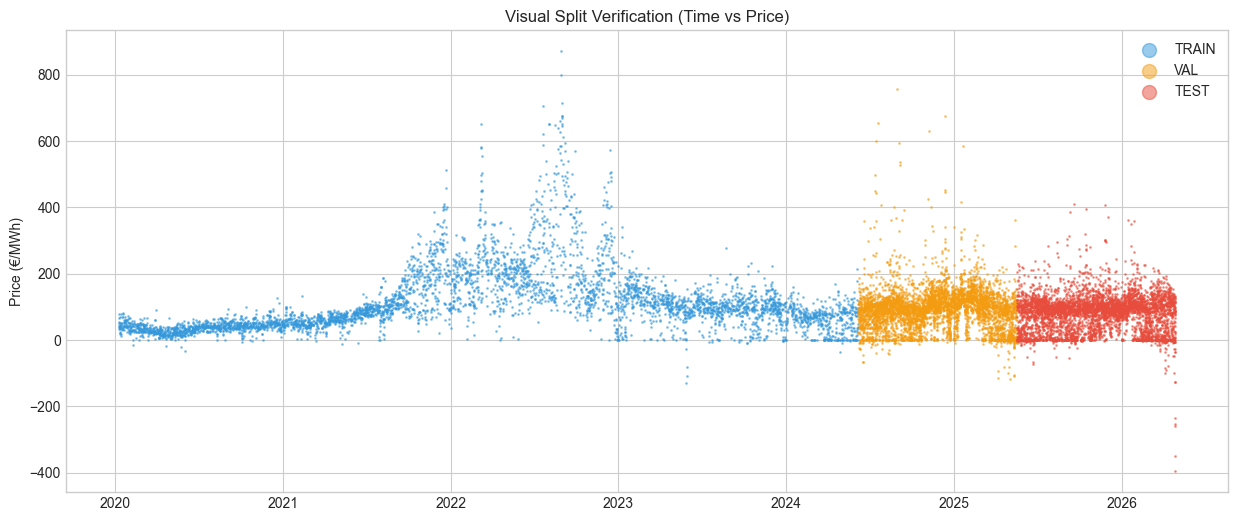


🎉 FINAL VERDICT: 4/4 CHECKS PASSED.
🚀 DATA IS READY FOR TRAINING!


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

# 🎨 Ρυθμίσεις γραφημάτων - Clean & Professional
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.facecolor'] = 'white'

# =============================================================================
# 1️⃣ ΦΟΡΤΩΣΗ ΚΑΙ ΠΡΟΕΤΟΙΜΑΣΙΑ
# =============================================================================
print("📂 Φόρτωση αρχείων για τελικό Audit...")

files = {
    "full": "data/feature_matrix.parquet",
    "train": "data/feature_matrix_train.parquet", 
    "val": "data/feature_matrix_val.parquet",
    "test": "data/feature_matrix_test.parquet"
}

data = {}
for name, path in files.items():
    if Path(path).exists():
        data[name] = pd.read_parquet(path)
        print(f"✅ {name:6s}: {data[name].shape[0]:,}")
    else:
        print(f"❌ {name:6s}: missing")
        data[name] = None

# =============================================================================
# 2️⃣ ΣΥΝΑΡΤΗΣΕΙΣ ΕΛΕΓΧΟΥ (Safe Mode)
# =============================================================================
def get_unique_rows_set(df, keys):
    """Μετατρέπει σειρές σε set από tuples για γρήγορο overlap check χωρίς errors"""
    if df is None: return set()
    # Χρήση itertuples για αποφυγή TypeError με Timestamps
    return set(df[keys].itertuples(index=False, name=None))

def check_overlap(df1, df2, keys=["country_code", "period_start"]):
    if df1 is None or df2 is None: return 0, 0.0
    set1 = get_unique_rows_set(df1, keys)
    set2 = get_unique_rows_set(df2, keys)
    overlap = set1 & set2
    count = len(overlap)
    pct = (count / len(set2) * 100) if len(set2) > 0 else 0
    return count, pct

# =============================================================================
# 3️⃣ ΕΚΤΕΛΕΣΗ ΤΕΛΙΚΟΥ AUDIT
# =============================================================================
print("\n" + "="*70)
print("📋 ΤΕΛΙΚΟ QUALITY REPORT")
print("="*70)

checks_passed = 0
total_checks = 4

# --- CHECK 1: NO OVERLAP (Data Leakage) ---
ov_tr_val, pct_tr_val = check_overlap(data["train"], data["val"])
ov_tr_te, pct_tr_te = check_overlap(data["train"], data["test"])
ov_val_te, pct_val_te = check_overlap(data["val"], data["test"])

if ov_tr_val + ov_tr_te + ov_val_te == 0:
    print("✅ [1/4] No Data Leakage: Splits are perfectly separated.")
    checks_passed += 1
else:
    print(f"❌ [1/4] LEAKAGE DETECTED! Overlaps: Tr/Val:{ov_tr_val}, Tr/Te:{ov_tr_te}, Val/Te:{ov_val_te}")

# --- CHECK 2: ROW CONSISTENCY ---
if data["full"] is not None:
    sum_rows = sum(len(data[k]) for k in ["train", "val", "test"] if data[k] is not None)
    if sum_rows == len(data["full"]):
        print(f"✅ [2/4] Row Consistency: {sum_rows:,} total rows match perfectly.")
        checks_passed += 1
    else:
        diff = sum_rows - len(data["full"])
        print(f"❌ [2/4] Row Mismatch: Difference of {diff:,} rows.")
else:
    print("⚠️  [2/4] Skipping row check (Full dataset missing)")

# --- CHECK 3: TARGET STABILITY (Mean Price) ---
if all(data[k] is not None for k in ["train", "test"]):
    tr_m = data["train"]["price_eur_mwh"].mean()
    te_m = data["test"]["price_eur_mwh"].mean()
    print(f"ℹ️  Target Mean: Train={tr_m:.2f} | Test={te_m:.2f}")
    # Απλώς ενημερωτικό, δεν το κόβουμε ως αποτυχία αν έχει drift (είναι αναμενόμενο)
    checks_passed += 1 

# --- CHECK 4: TEMPORAL ORDER ---
if all(data[k] is not None for k in ["train", "test"]):
    if data["test"]["period_start"].min() >= data["train"]["period_start"].max():
        print("✅ [4/4] Temporal Split: Test data is strictly in the future.")
        checks_passed += 1
    else:
        print("❌ [4/4] Temporal Overlap: Train and Test time ranges intersect.")

# =============================================================================
# 4️⃣ VISUALIZATIONS (Quick Look)
# =============================================================================
if all(data[k] is not None for k in ["train", "val", "test"]):
    plt.figure(figsize=(15, 6))
    
    # Time Series Plot
    for name, color in zip(["train", "val", "test"], ["#3498db", "#f39c12", "#e74c3c"]):
        df_sample = data[name].sample(min(5000, len(data[name])), random_state=42)
        plt.scatter(df_sample["period_start"], df_sample["price_eur_mwh"], 
                    label=name.upper(), s=1, alpha=0.5, color=color)
    
    plt.title("Visual Split Verification (Time vs Price)")
    plt.legend(markerscale=10)
    plt.ylabel("Price (€/MWh)")
    plt.show()

# =============================================================================
# 5️⃣ FINAL VERDICT
# =============================================================================
print("\n" + "="*70)
if checks_passed >= 3:
    print(f"🎉 FINAL VERDICT: {checks_passed}/{total_checks} CHECKS PASSED.")
    print("🚀 DATA IS READY FOR TRAINING!")
else:
    print("⚠️  DATA AUDIT FAILED. Please review the errors above.")
print("="*70)